In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#-----------data preprocessing------------
df=pd.read_csv("Processed_data.csv")
df

,Traffic_Flag,Login_Attempts,Connection_Duration,Packets_Per_Second,Error_Rate,Packet_Size,Label
0,0,3,334.0,2971.0,0.342323,1006.0,1
1,1,15,687.0,2971.0,0.632884,1006.0,0
2,2,12,559.0,3112.0,0.412128,1324.0,0
3,3,16,196.0,4339.0,0.926413,1865.0,1
4,1,19,777.0,5569.0,0.684656,584.0,1
...,...,...,...,...,...,...,...
2995,1,16,494.0,58.0,0.314579,1692.0,0
2996,1,1,463.0,670.0,0.113115,311.0,0
2997,1,8,356.0,3396.0,0.051554,1448.0,0
2998,1,3,208.0,3307.0,0.364573,1238.0,0


In [20]:
x=df.drop('Label',axis=1)
y=df['Label']
#Train-test split
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=4)

In [21]:
#feature scaling(Standarisation)
ss=StandardScaler()

x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)


Best K: 9 



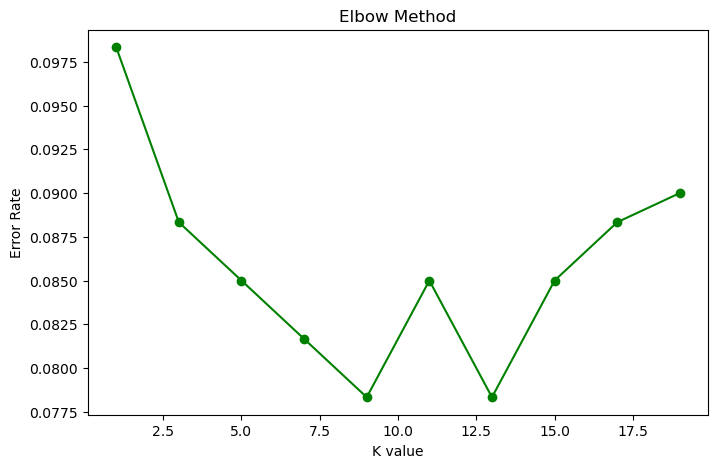

In [27]:
#training model
from sklearn.neighbors import KNeighborsClassifier

error_rates = []

# try different K values to find the optimal value of K
for k in range(1, 21, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    pred_k = knn.predict(x_test)
    
    error = (pred_k != y_test).mean()
    error_rates.append(error)
    
k_values = list(range(1, 21, 2))
best_k = k_values[error_rates.index(min(error_rates))]
print("Best K:", best_k,"\n")
# plot graph
plt.figure(figsize=(8,5))
plt.plot(range(1,21,2), error_rates, marker='o',color='green')
plt.xlabel("K value")
plt.ylabel("Error Rate")
plt.title("Elbow Method")
plt.show()

In [28]:
#According to graph we are getting optimal value of K as 9
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train, y_train)


,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None
